# Netflix Movies & TV Shows Analysis

## Project Overview

This project analyzes Netflix movies and TV shows to identify patterns in content type, release year, country, rating, and genre.

The analysis aims to understand the characteristics and distribution of Netflix content and how the content library varies across different categories.

### Objectives

- Understand the structure of the Netflix dataset
- Perform data cleaning and preprocessing
- Compare Movies and TV Shows
- Analyze content additions over time
- Identify countries with the most titles
- Analyze content ratings
- Identify the most common genres
- Generate data-driven insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [ ]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 8807
Jumlah kolom: 12


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## 1. Data Understanding

The dataset contains information about Netflix movies and TV shows, including content type, title, director, cast, country, date added, release year, rating, duration, genre, and description.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
director,2634
cast,825
country,831
date_added,10
rating,4
duration,3


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

,0
director,29.908028
country,9.435676
cast,9.367549
date_added,0.113546
rating,0.045418
duration,0.034064


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Duplicate show_id:", df["show_id"].duplicated().sum())

Duplicate show_id: 0


In [ ]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

In [ ]:
df["date_added"] = df["date_added"].fillna("Unknown")

In [ ]:
df["duration"] = df["duration"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
df["year_added"] = (
    df["date_added"]
    .str.extract(r"(\d{4})")
)

In [ ]:
df[["date_added", "year_added"]].head()

,date_added,year_added
0,"September 25, 2021",2021
1,"September 24, 2021",2021
2,"September 24, 2021",2021
3,"September 24, 2021",2021
4,"September 24, 2021",2021


In [ ]:
df["year_added"].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,429


## 2. Content Type Analysis

This analysis compares the distribution of Movies and TV Shows in the Netflix dataset.

In [ ]:
content_type = df["type"].value_counts()

content_type

,count
type,
Movie,6131
TV Show,2676


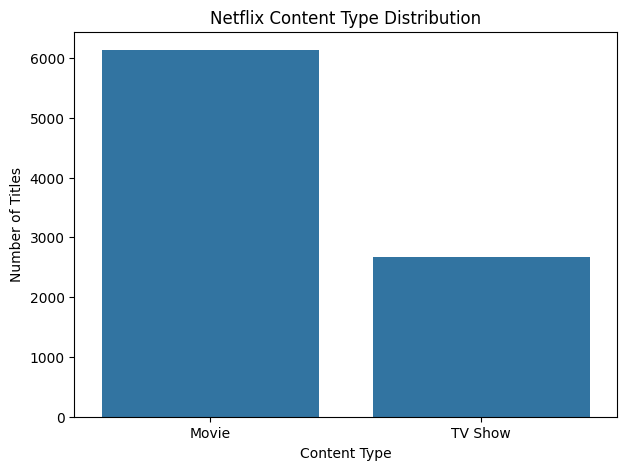

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=content_type.index,
    y=content_type.values
)

plt.title("Netflix Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [ ]:
content_percentage = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

content_percentage

,proportion
type,
Movie,69.62
TV Show,30.38


## 3. Content Added Over Time

This analysis examines the number of Netflix titles added to the dataset each year to identify periods with the highest content additions.

In [ ]:
year_added_count = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

year_added_count

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,429


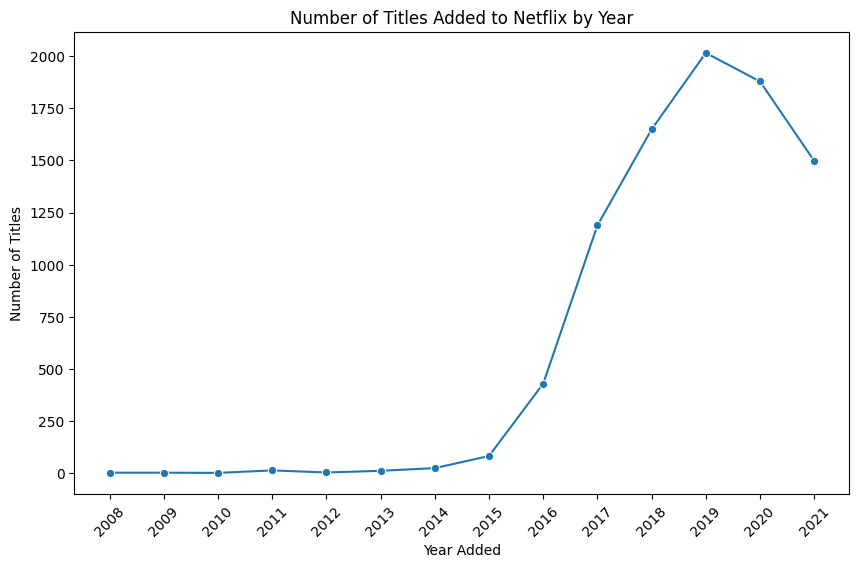

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=year_added_count.index,
    y=year_added_count.values,
    marker="o"
)

plt.title("Number of Titles Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [ ]:
peak_year = year_added_count.idxmax()
peak_count = year_added_count.max()

print(f"Peak Year: {peak_year}")
print(f"Titles Added: {peak_count:,}")

Peak Year: 2019
Titles Added: 2,016


In [ ]:
content_by_year = (
    df.groupby(["year_added", "type"])
    .size()
    .reset_index(name="count")
)

content_by_year.head()

,year_added,type,count
0,2008,Movie,1
1,2008,TV Show,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,13


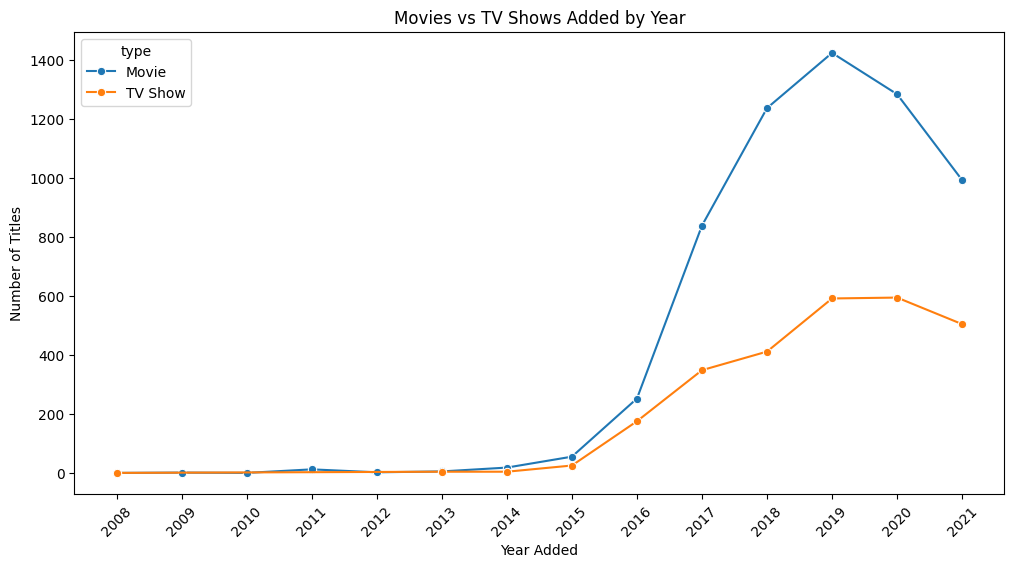

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=content_by_year,
    x="year_added",
    y="count",
    hue="type",
    marker="o"
)

plt.title("Movies vs TV Shows Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [ ]:
df["primary_country"] = (
    df["country"]
    .str.split(",")
    .str[0]
    .str.strip()
)

country_count = (
    df["primary_country"]
    .value_counts()
    .head(10)
)

country_count

,count
primary_country,
United States,3211
India,1008
Unknown,831
United Kingdom,628
Canada,271
Japan,259
France,212
South Korea,211
Spain,181


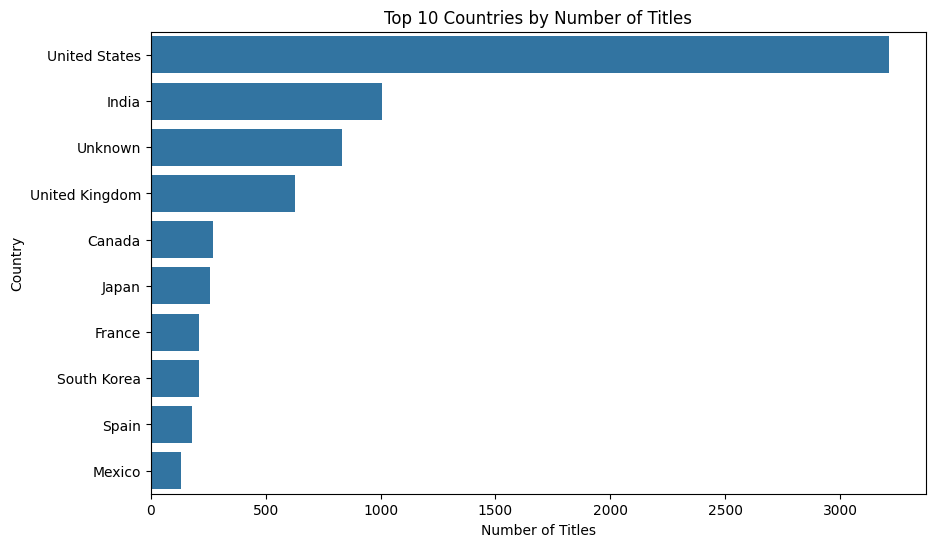

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=country_count.values,
    y=country_count.index
)

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

## 4. Rating Analysis

This analysis examines the distribution of Netflix titles across different content ratings to understand the dominant audience categories in the dataset.

In [ ]:
rating_count = (
    df["rating"]
    .value_counts()
)

rating_count

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


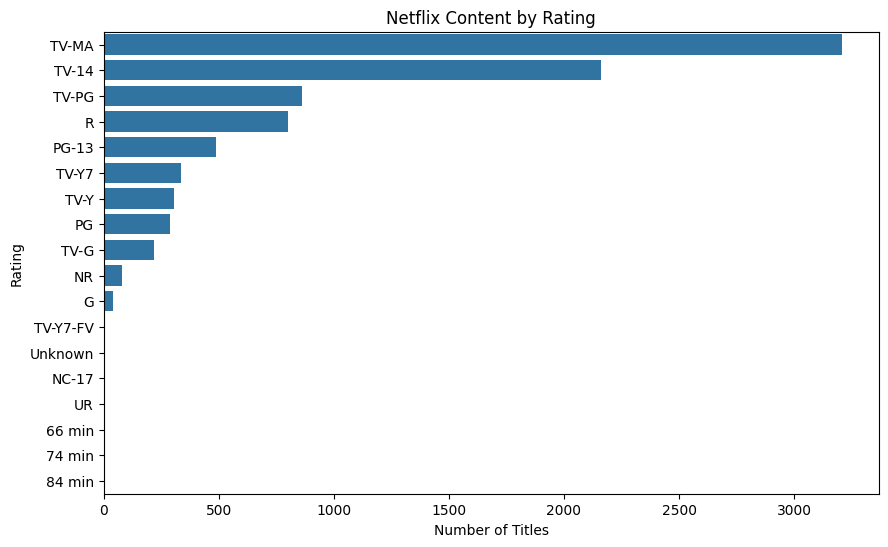

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=rating_count.values,
    y=rating_count.index
)

plt.title("Netflix Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

In [ ]:
top_rating = rating_count.idxmax()
top_rating_count = rating_count.max()

print("Most Common Rating:", top_rating)
print("Number of Titles:", top_rating_count)

Most Common Rating: TV-MA
Number of Titles: 3207


In [ ]:
genre_df = df[["show_id", "listed_in"]].copy()

genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

In [ ]:
genre_df = genre_df.explode("listed_in")

In [ ]:
genre_count = (
    genre_df["listed_in"]
    .value_counts()
)

genre_count.head(15)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


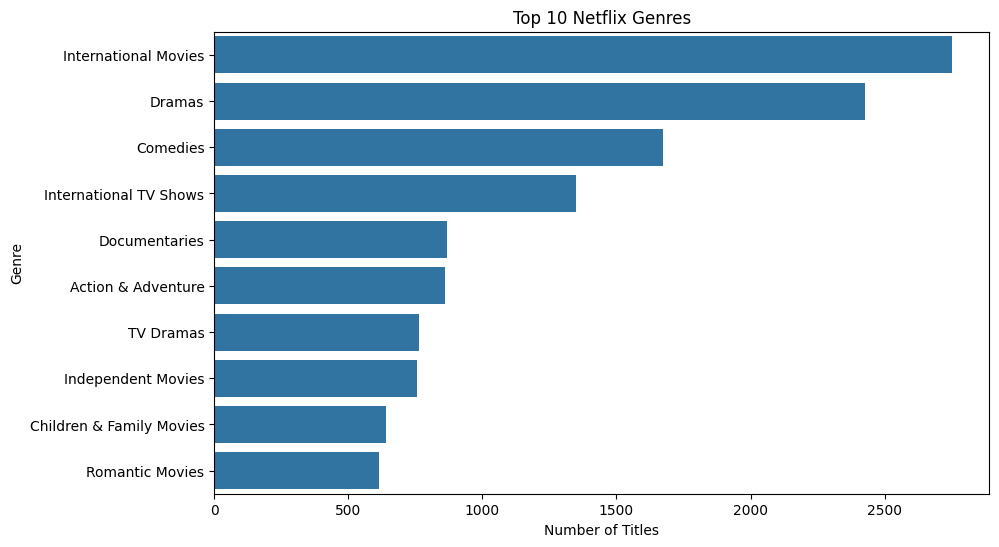

In [ ]:
top_genres = genre_count.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [ ]:
genre_type_df = df[["show_id", "type", "listed_in"]].copy()

genre_type_df["listed_in"] = (
    genre_type_df["listed_in"]
    .str.split(", ")
)

genre_type_df = genre_type_df.explode("listed_in")

In [ ]:
genre_type_count = (
    genre_type_df
    .groupby(["listed_in", "type"])
    .size()
    .reset_index(name="count")
)

In [ ]:
top_genre_names = (
    genre_type_df["listed_in"]
    .value_counts()
    .head(10)
    .index
)

genre_type_top = genre_type_count[
    genre_type_count["listed_in"].isin(top_genre_names)
]

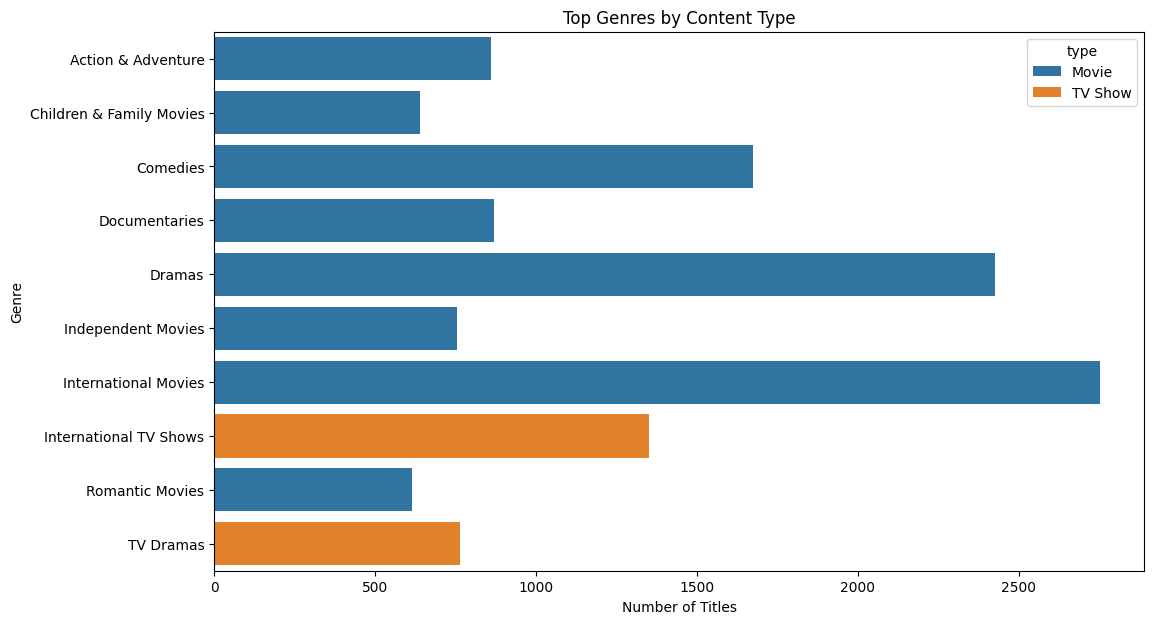

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=genre_type_top,
    x="count",
    y="listed_in",
    hue="type"
)

plt.title("Top Genres by Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [ ]:
movie_duration = df[df["type"] == "Movie"].copy()

movie_duration["duration_minutes"] = (
    movie_duration["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

movie_duration["duration_minutes"].describe()

,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


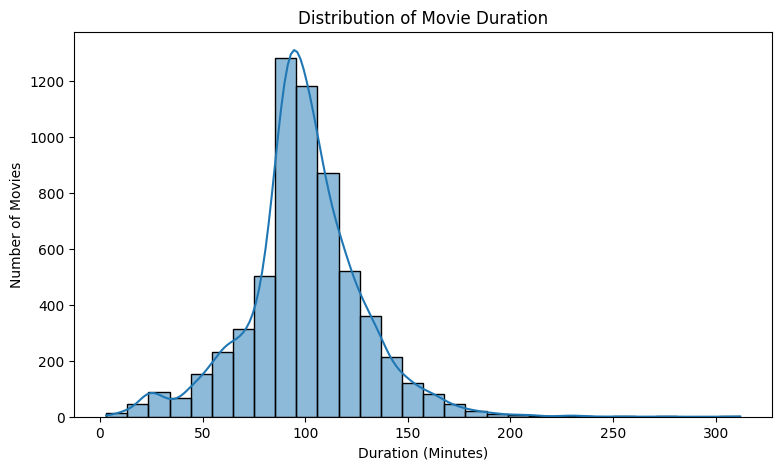

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=movie_duration,
    x="duration_minutes",
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [ ]:
tv_duration = df[df["type"] == "TV Show"].copy()

tv_duration["seasons"] = (
    tv_duration["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

tv_duration["seasons"].value_counts().sort_index()

,count
seasons,
1.0,1793
2.0,425
3.0,199
4.0,95
5.0,65
6.0,33
7.0,23
8.0,17
9.0,9


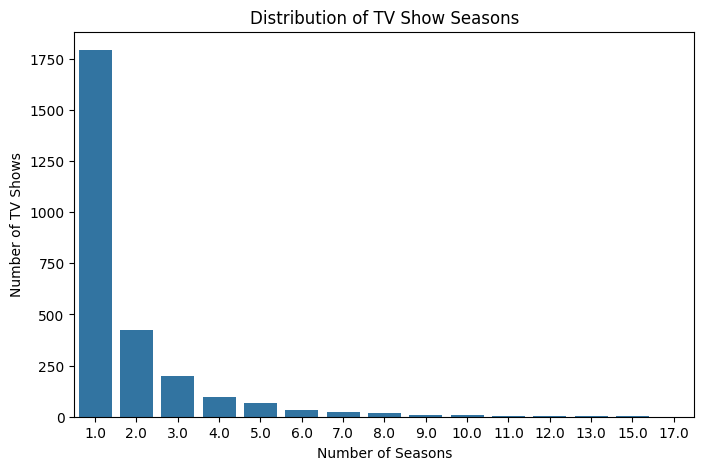

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=tv_duration,
    x="seasons"
)

plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.show()

## 5. Key Findings

### 1. Content Type

Movies represent 69.62% of the titles in the dataset, while TV Shows represent 30.38%. This indicates that the Netflix content library in this dataset is dominated by Movies.

### 2. Content Growth

The highest number of titles was added in 2019, with 2,016 titles. Content additions increased substantially from 2015 onward before reaching a peak in 2019.

### 3. Country

The United States was the most common primary country, with 3,211 titles, followed by India with 1,008 titles. Country comparisons should be interpreted carefully because some titles involve multiple countries.

### 4. Rating

TV-MA was the most common content rating, with 3,207 titles, followed by TV-14 with 2,160 titles.

### 5. Genre

International Movies was the most frequently listed genre with 2,752 titles, followed by Dramas and Comedies. The genre analysis also showed differences between Movies and TV Shows, with several movie-oriented genres dominated by Movies and TV-oriented genres dominated by TV Shows.

## 6. Conclusion

This project analyzed Netflix Movies and TV Shows based on content type, content addition trends, country, rating, genre, and duration.

The analysis showed that Movies make up the majority of the dataset, accounting for 69.62% of the titles. Content additions increased significantly during the later years of the dataset, reaching the highest level in 2019 with 2,016 titles.

The United States was the most common primary country, while TV-MA was the most common content rating. International Movies, Dramas, and Comedies were among the most frequently listed genres.

The genre analysis also demonstrated differences between Movies and TV Shows. Movie-oriented genres were largely dominated by Movies, while categories such as International TV Shows and TV Dramas were more strongly represented by TV Shows.

Overall, the analysis provides an overview of the composition and evolution of Netflix's content library within the dataset.